# Nearest Neighbour Vehicle Routing Problem

This project builds a simple capacitated vehicle routing problem (CVRP) and solves it with a nearest-neighbour construction heuristic. The goal is to create feasible delivery routes from one depot to multiple customer stops while respecting vehicle capacity.


## Problem Setup

- One depot is located at coordinate `(50, 50)`.
- Twelve customer stops have coordinates and demand values.
- Each vehicle can carry at most **18 demand units**.
- Distances are Euclidean distances on the coordinate plane.
- The heuristic repeatedly chooses the nearest unvisited customer that still fits in the current vehicle.


In [1]:
from math import ceil, hypot

customers = {
    0: {'name': 'Depot', 'x': 50, 'y': 50, 'demand': 0},
    1: {'name': 'Downtown', 'x': 38, 'y': 64, 'demand': 4},
    2: {'name': 'Riverside', 'x': 24, 'y': 54, 'demand': 3},
    3: {'name': 'North Gate', 'x': 46, 'y': 78, 'demand': 5},
    4: {'name': 'Hill Park', 'x': 65, 'y': 82, 'demand': 2},
    5: {'name': 'East Market', 'x': 78, 'y': 60, 'demand': 6},
    6: {'name': 'South Clinic', 'x': 62, 'y': 34, 'demand': 4},
    7: {'name': 'West School', 'x': 28, 'y': 32, 'demand': 5},
    8: {'name': 'Airport', 'x': 84, 'y': 28, 'demand': 3},
    9: {'name': 'University', 'x': 18, 'y': 76, 'demand': 2},
    10: {'name': 'Stadium', 'x': 42, 'y': 20, 'demand': 4},
    11: {'name': 'Library', 'x': 58, 'y': 66, 'demand': 3},
    12: {'name': 'Old Town', 'x': 72, 'y': 46, 'demand': 5},
}

vehicle_capacity = 18
total_demand = sum(stop['demand'] for stop in customers.values())

print(f"Loaded {len(customers) - 1} customer stops plus one depot.")
print(f"Vehicle capacity: {vehicle_capacity} demand units")
print(f"Total demand: {total_demand}")
print(f"Minimum possible number of vehicles by capacity lower bound: {ceil(total_demand / vehicle_capacity)}")


Loaded 12 customer stops plus one depot.
Vehicle capacity: 18 demand units
Total demand: 46
Minimum possible number of vehicles by capacity lower bound: 3


## Heuristic Result

The nearest-neighbour heuristic gives the following feasible routes. It is fast and intuitive, but it is not guaranteed to be globally optimal.

Vehicle | Load | Distance | Route
--- | ---: | ---: | ---
1 | 17/18 | 132.2 | Depot -> Library -> North Gate -> Downtown -> Riverside -> University -> Depot
2 | 17/18 | 111.7 | Depot -> South Clinic -> Old Town -> East Market -> Hill Park -> Depot
3 | 12/18 | 130.1 | Depot -> West School -> Stadium -> Airport -> Depot


In [2]:
def distance(a, b):
    return hypot(customers[a]['x'] - customers[b]['x'], customers[a]['y'] - customers[b]['y'])


def route_distance(route):
    return sum(distance(route[i], route[i + 1]) for i in range(len(route) - 1))


def nearest_neighbor_cvrp(customers, vehicle_capacity):
    unvisited = set(customers) - {0}
    routes = []

    while unvisited:
        route = [0]
        current = 0
        load = 0

        while True:
            feasible = [node for node in unvisited if load + customers[node]['demand'] <= vehicle_capacity]
            if not feasible:
                break

            next_node = min(feasible, key=lambda node: (distance(current, node), node))
            route.append(next_node)
            load += customers[next_node]['demand']
            unvisited.remove(next_node)
            current = next_node

        route.append(0)
        routes.append({'route': route, 'load': load, 'distance': route_distance(route)})

    return routes


def route_label(route):
    return ' -> '.join(customers[node]['name'] for node in route)


routes = nearest_neighbor_cvrp(customers, vehicle_capacity)

for idx, result in enumerate(routes, start=1):
    print(f"Vehicle {idx}: load {result['load']}/{vehicle_capacity}, distance {result['distance']:.1f}")
    print(f"  {route_label(result['route'])}")

print(f"Total distance: {sum(result['distance'] for result in routes):.1f}")


Vehicle 1: load 17/18, distance 132.2
  Depot -> Library -> North Gate -> Downtown -> Riverside -> University -> Depot
Vehicle 2: load 17/18, distance 111.7
  Depot -> South Clinic -> Old Town -> East Market -> Hill Park -> Depot
Vehicle 3: load 12/18, distance 130.1
  Depot -> West School -> Stadium -> Airport -> Depot
Total distance: 374.1


## Route Visualization

The map below shows the depot, customer demand points, and the constructed vehicle routes.


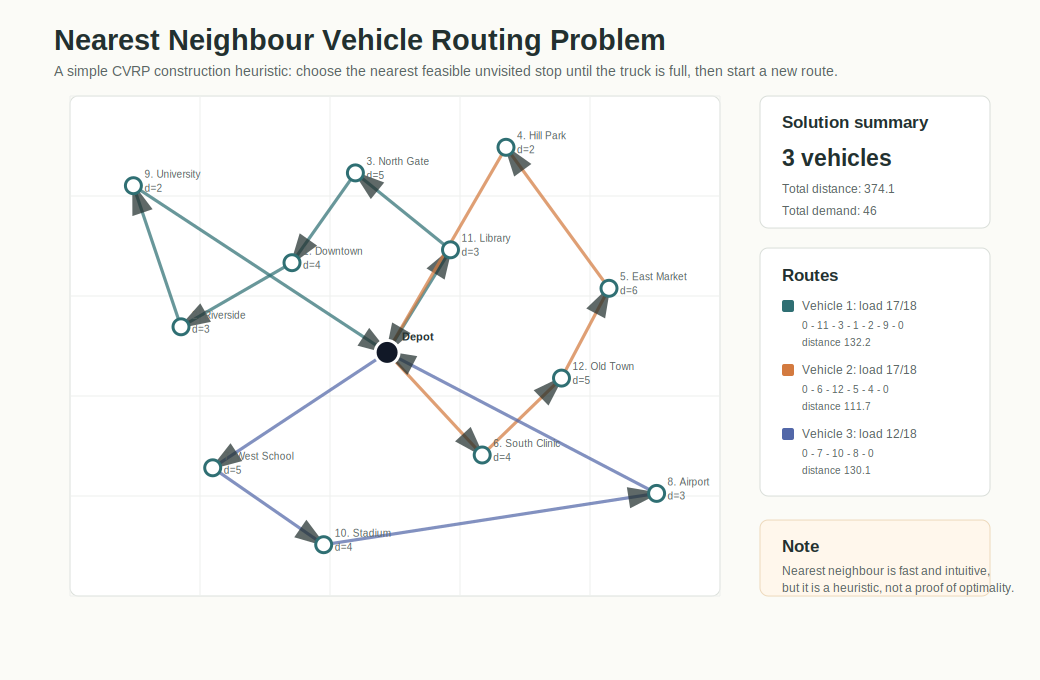

In [3]:
from IPython.display import SVG, display

route_colors = ['#2f6f73', '#d37a3f', '#5267a8', '#9c4f74', '#6f7f2f']
min_x = min(stop['x'] for stop in customers.values()) - 8
max_x = max(stop['x'] for stop in customers.values()) + 8
min_y = min(stop['y'] for stop in customers.values()) - 8
max_y = max(stop['y'] for stop in customers.values()) + 8
width, height = 1040, 680
plot_x, plot_y, plot_w, plot_h = 70, 96, 650, 500


def sx(x):
    return plot_x + (x - min_x) / (max_x - min_x) * plot_w


def sy(y):
    return plot_y + plot_h - (y - min_y) / (max_y - min_y) * plot_h


svg = []
svg.append(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-label="Nearest neighbour vehicle routing result">')
svg.append('<rect width="100%" height="100%" fill="#fbfbf7"/>')
svg.append('<defs><marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth"><path d="M0,0 L0,6 L9,3 z" fill="#22302f" opacity="0.72"/></marker></defs>')
svg.append('<style>text{font-family:Arial,Helvetica,sans-serif;fill:#22302f}.title{font-size:29px;font-weight:700}.sub{font-size:14px;fill:#5a6563}.h{font-size:17px;font-weight:700}.small{font-size:12px;fill:#5a6563}.tiny{font-size:10px;fill:#5a6563}.value{font-size:23px;font-weight:700}.label{font-size:11px;font-weight:700}</style>')
svg.append('<text x="54" y="50" class="title">Nearest Neighbour Vehicle Routing Problem</text>')
svg.append('<text x="54" y="76" class="sub">A simple CVRP construction heuristic: choose the nearest feasible unvisited stop until the truck is full, then start a new route.</text>')
svg.append(f'<rect x="{plot_x}" y="{plot_y}" width="{plot_w}" height="{plot_h}" rx="8" fill="#ffffff" stroke="#d9ded9"/>')

for i in range(6):
    gx = plot_x + i * plot_w / 5
    gy = plot_y + i * plot_h / 5
    svg.append(f'<line x1="{gx:.1f}" y1="{plot_y}" x2="{gx:.1f}" y2="{plot_y + plot_h}" stroke="#edf0ed"/>')
    svg.append(f'<line x1="{plot_x}" y1="{gy:.1f}" x2="{plot_x + plot_w}" y2="{gy:.1f}" stroke="#edf0ed"/>')

for route_index, result in enumerate(routes):
    color = route_colors[route_index % len(route_colors)]
    route = result['route']
    for i in range(len(route) - 1):
        a, b = route[i], route[i + 1]
        svg.append(
            f'<line x1="{sx(customers[a]["x"]):.1f}" y1="{sy(customers[a]["y"]):.1f}" '
            f'x2="{sx(customers[b]["x"]):.1f}" y2="{sy(customers[b]["y"]):.1f}" '
            f'stroke="{color}" stroke-width="3.2" opacity="0.72" marker-end="url(#arrow)"/>'
        )

for node, stop in customers.items():
    x, y = sx(stop['x']), sy(stop['y'])
    if node == 0:
        svg.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="12" fill="#111827" stroke="#ffffff" stroke-width="3"/>')
        svg.append(f'<text x="{x + 15:.1f}" y="{y - 12:.1f}" class="label">Depot</text>')
    else:
        svg.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="8" fill="#ffffff" stroke="#2f6f73" stroke-width="3"/>')
        svg.append(f'<text x="{x + 11:.1f}" y="{y - 8:.1f}" class="tiny">{node}. {stop["name"]}</text>')
        svg.append(f'<text x="{x + 11:.1f}" y="{y + 6:.1f}" class="tiny">d={stop["demand"]}</text>')

panel_x = 760
total_distance = sum(result['distance'] for result in routes)
total_demand = sum(stop['demand'] for stop in customers.values())
svg.append(f'<rect x="{panel_x}" y="96" width="230" height="132" rx="8" fill="#ffffff" stroke="#d9ded9"/>')
svg.append(f'<text x="{panel_x + 22}" y="128" class="h">Solution summary</text>')
svg.append(f'<text x="{panel_x + 22}" y="166" class="value">{len(routes)} vehicles</text>')
svg.append(f'<text x="{panel_x + 22}" y="193" class="small">Total distance: {total_distance:.1f}</text>')
svg.append(f'<text x="{panel_x + 22}" y="215" class="small">Total demand: {total_demand}</text>')

svg.append(f'<rect x="{panel_x}" y="248" width="230" height="248" rx="8" fill="#ffffff" stroke="#d9ded9"/>')
svg.append(f'<text x="{panel_x + 22}" y="281" class="h">Routes</text>')
for route_index, result in enumerate(routes):
    y = 316 + route_index * 64
    color = route_colors[route_index % len(route_colors)]
    route_ids = ' - '.join(str(node) for node in result['route'])
    svg.append(f'<rect x="{panel_x + 22}" y="{y - 16}" width="12" height="12" rx="2" fill="{color}"/>')
    svg.append(f'<text x="{panel_x + 42}" y="{y - 6}" class="small">Vehicle {route_index + 1}: load {result["load"]}/{vehicle_capacity}</text>')
    svg.append(f'<text x="{panel_x + 42}" y="{y + 13}" class="tiny">{route_ids}</text>')
    svg.append(f'<text x="{panel_x + 42}" y="{y + 30}" class="tiny">distance {result["distance"]:.1f}</text>')

svg.append(f'<rect x="{panel_x}" y="520" width="230" height="76" rx="8" fill="#fff7ec" stroke="#edd9bc"/>')
svg.append(f'<text x="{panel_x + 22}" y="552" class="h">Note</text>')
svg.append(f'<text x="{panel_x + 22}" y="575" class="small">Nearest neighbour is fast and intuitive,</text>')
svg.append(f'<text x="{panel_x + 22}" y="592" class="small">but it is a heuristic, not a proof of optimality.</text>')
svg.append('</svg>')

display(SVG(''.join(svg)))


## Possible Extensions

- Compare nearest neighbour with a savings heuristic or 2-opt route improvement.
- Add time windows for each customer.
- Convert the same problem into a mixed-integer linear programming model for exact optimization on small instances.
